## Data Augmentation for Skeleton Based Action Recognition

In [1]:
from torch.utils.data import DataLoader
import os

os.chdir('./meta-har/STGAT')

from method_choose.data_choose import init_seed
from utility.log import TimerBlock
from dataset.ntu_skeleton import NTU_SKE

# os.chdir('/tf')

In [2]:
train_data_param = {
    'data_path': './prep_dataset/ntu_60/xsub/train_data_joint.npy',
    'label_path': './prep_dataset/ntu_60/xsub/train_label.pkl',
    'random_choose': True,
    'center_choose': False,
    'window_size': 150,
    'final_size': 128,
    'num_skip_frame': None,
    'decouple_spatial': False
}

val_data_param = {
    'data_path': './prep_dataset/ntu_60/xsub/val_data_joint.npy',
    'label_path': './prep_dataset/ntu_60/xsub/val_label.pkl',
    'random_choose': False,
    'center_choose': True,
    'window_size': 150,
    'final_size': 128,
    'num_skip_frame': None,
    'decouple_spatial': False
}

data_set_train = NTU_SKE(mode='train', **train_data_param)
data_set_val = NTU_SKE(mode='eval_rot', **val_data_param)

batch_size = 32
workers = 0
pin_memory = False

In [3]:
data_loader_val = DataLoader(data_set_val, batch_size=batch_size, shuffle=False,
                                num_workers=workers, drop_last=False, pin_memory=pin_memory,
                                worker_init_fn=init_seed)
data_loader_train = DataLoader(data_set_train, batch_size=batch_size, shuffle=True,
                                num_workers=workers, drop_last=True, pin_memory=pin_memory,
                                worker_init_fn=init_seed)

In [4]:
# visualize the data
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(data_loader, block):
    for i, (data, target) in enumerate(data_loader):
        block.log('data shape: {}'.format(data.shape))
        block.log('target shape: {}'.format(target.shape))
        if i == 0:
            break

        for j in range(data.shape[1]):
            plt.figure()
            plt.imshow(data[0, j, :, :].cpu().numpy(), cmap='gray')
            plt.title('frame {}'.format(j))
            plt.show()

        break

In [93]:
import matplotlib.pyplot as plt


# Interpolation function
def interpolate_line(dx, dy, dx2, dy2):
    xdist = abs(dx2 - dx)
    ydist = abs(dy2 - dy)

    if xdist > ydist:
        xrange = np.arange(dx, dx2, np.sign(dx2 - dx)).tolist() + [dx2]
        yrange = np.arange(
            dy, dy2, np.sign(dy2 - dy) * abs((dy2 - dy) / (dx2 - dx))
        ).tolist() + [dy2]
    else:
        yrange = np.arange(dy, dy2, np.sign(dy2 - dy)).tolist() + [dy2]
        xrange = np.arange(
            dx, dx2, np.sign(dx2 - dx) * abs((dx2 - dx) / (dy2 - dy))
        ).tolist() + [dx2]

    return list(zip(xrange, yrange))


def visualize_skeleton(skeleton, ax):
    # Define the connections between joints
    connections = [
        (1, 13),
        (1, 17),
        (1, 2),
        (2, 21),
        (21, 5),
        (21, 9),
        (21, 3),
        (3, 4),
        (5, 6),
        (6, 7),
        (7, 8),
        (9, 10),
        (10, 11),
        (11, 12),
        (13, 14),
        (14, 15),
        (15, 16),
        (17, 18),
        (18, 19),
        (19, 20),
    ]
    # connections = [
    #     (1, 0),
    #     (20, 2),
    #     (2, 3),
    #     (20, 4),
    #     (4, 5),
    #     (5, 6),
    #     (20, 8),
    #     (8, 9),
    #     (9, 10),
    #     (0, 12),
    #     (12, 13),
    #     (13, 14),
    #     (0, 16),
    #     (16, 17),
    #     (17, 18),
    #     (1, 7),
    #     (7, 7),
    #     (11, 11),
    # ]

    # Plot each body
    for body in skeleton:
        # without interpolation
        xs, ys = [], []
        for i, j in connections:
            xs.extend([body[i - 1][0], body[j - 1][0]])
            ys.extend([body[i - 1][1], body[j - 1][1]])
            
        ax.plot(xs, ys, marker="o")

        # with interpolation
        # for (i, j) in connections:
        #     line_points = interpolate_line(body[i][0], body[i][1], body[j][0], body[j][1])
        #     for (x, y) in line_points:
        #         ax.plot(x, y, 'o')  # Plot each| point as a blue dot

Joint coordinates:
[[ 0.03723455 -2.4991257 ]
 [ 0.02814003 -2.7276928 ]
 [ 0.04320437 -2.9338434 ]
 [-0.14840609 -3.0984552 ]
 [ 0.16498064 -2.9080744 ]
 [ 0.2974378  -2.4686556 ]
 [ 0.39825088 -2.0217874 ]
 [ 0.4482581  -1.8726573 ]
 [-0.09600379 -2.7751217 ]
 [ 0.1935542  -2.4277859 ]
 [ 0.36573195 -1.9558947 ]
 [ 0.38899305 -1.7391675 ]
 [ 0.12902746 -2.502501  ]
 [ 0.11070879 -1.8219333 ]
 [ 0.04520326 -2.1528983 ]
 [ 0.14340498 -1.9358873 ]
 [ 0.04839551 -2.401661  ]
 [ 0.18663879 -1.6336858 ]
 [ 0.1226829  -1.4792707 ]
 [ 0.2916568  -1.5207335 ]
 [ 0.0353968  -2.8860326 ]
 [ 0.45723644 -1.6822735 ]
 [ 0.39787766 -1.7785801 ]
 [ 0.43686038 -1.5895336 ]
 [ 0.47364706 -1.6864281 ]]


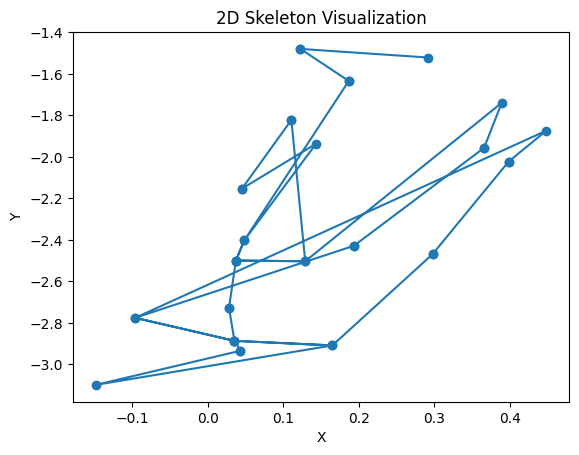

In [141]:
# get one sample from data_loader_train

# Get a batch of data
for inputs, targets in data_loader_train:
    # Select the first sample, first channel, and first frame
    sample = inputs[0, 0, 0, :, :]
    
    # Print the joint coordinates for debugging
    print("Joint coordinates:")
    print(sample.numpy())

    # Visualize the first sample's first channel and first frame
    fig, ax = plt.subplots()
    visualize_skeleton([sample.numpy()], ax)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('2D Skeleton Visualization')
    plt.show()

    # Break after the first batch for demonstration purposes
    break

In [ ]:
with TimerBlock("Visualize Train Data") as block:
    visualize_data(data_loader_train, block)